# 6CS012 - Worksheet 3: Modeling the Neuron
## From MCP to Perceptron, Its Learning Algorithm, and Limitations
---

## Task 1: Implementation of MCP Neurons

In [1]:
import numpy as np

# ── AND Gate ──────────────────────────────────────────────────────────────────
def MCP_Neurons_AND(X1, X2, T):
    """
    Implements AND operation with MCP Neuron for two inputs.
    Arguments:
        X1 (list): Array of binary values.
        X2 (list): Array of binary values.
        T  (int/float): Threshold value.
    Returns:
        state_neuron (list): Neuron output (1 or 0) for each input pair.
    """
    assert len(X1) == len(X2), "Input arrays must have equal length."

    # Step 1: element-wise sum of the two inputs
    aggregated = [x1 + x2 for x1, x2 in zip(X1, X2)]

    # Step 2 & 3: compare against threshold
    state_neuron = [1 if s >= T else 0 for s in aggregated]

    return state_neuron

# Example usage
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T_and = 2   # Both inputs must be 1 → threshold = 2
result_and = MCP_Neurons_AND(X1, X2, T_and)
print(f"AND gate | inputs {X1} and {X2} | threshold {T_and}")
print(f"Output : {result_and}")
print(f"Expected: [0, 0, 0, 1]")


AND gate | inputs [0, 0, 1, 1] and [0, 1, 0, 1] | threshold 2
Output : [0, 0, 0, 1]
Expected: [0, 0, 0, 1]


In [2]:
# ── OR Gate ───────────────────────────────────────────────────────────────────
def MCP_Neurons_OR(X1, X2, T):
    """
    Implements OR operation with MCP Neuron for two inputs.
    Arguments:
        X1 (list): Array of binary values.
        X2 (list): Array of binary values.
        T  (int/float): Threshold value.
    Returns:
        state_neuron (list): Neuron output (1 or 0) for each input pair.
    """
    assert len(X1) == len(X2), "Input arrays must have equal length."

    # Step 1: element-wise sum
    aggregated = [x1 + x2 for x1, x2 in zip(X1, X2)]

    # Step 2 & 3: compare against threshold
    state_neuron = [1 if s >= T else 0 for s in aggregated]

    return state_neuron

# Example usage
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T_or = 1    # At least one input must be 1 → threshold = 1
result_or = MCP_Neurons_OR(X1, X2, T_or)
print(f"OR gate  | inputs {X1} and {X2} | threshold {T_or}")
print(f"Output : {result_or}")
print(f"Expected: [0, 1, 1, 1]")


OR gate  | inputs [0, 0, 1, 1] and [0, 1, 0, 1] | threshold 1
Output : [0, 1, 1, 1]
Expected: [0, 1, 1, 1]


### Question 1: Limitations of MCP Neurons

1. **Fixed (hand-crafted) threshold** – The threshold *T* must be set manually; there is no mechanism for the neuron to learn it from data.
2. **Binary inputs only** – Inputs must be 0 or 1; real-valued (continuous) inputs are not supported.
3. **No learnable weights** – All inputs are treated equally (each has an implicit weight of 1). The model cannot assign different importance to different features.
4. **Cannot solve non-linearly separable problems** – A single MCP neuron draws a linear decision boundary, so problems like XOR are unsolvable by one neuron.
5. **No learning algorithm** – The MCP model has no procedure to automatically adjust its parameters from examples.
6. **Boolean outputs only** – Output is strictly 0 or 1; probabilistic or continuous outputs are impossible.
7. **Inhibitory inputs are absolute** – A single inhibitory input immediately forces output to 0, regardless of all other inputs.

---

### Question 2: Can we solve XOR with MCP Neurons?

**Single MCP neuron → NO.** XOR is not linearly separable (no single straight line can separate the two classes in 2-D input space).

**Two-layer MCP network → YES.** We can decompose XOR as:

```
XOR(x1, x2) = AND( OR(x1,x2), NAND(x1,x2) )
```

| x1 | x2 | OR (T=1) | NAND (T<2) | AND of both (T=2) | XOR |
|----|----|---------:|----------:|------------------:|-----|
|  0 |  0 |    0     |     1     |         0        |  0  |
|  0 |  1 |    1     |     1     |         1        |  1  |
|  1 |  0 |    1     |     1     |         1        |  1  |
|  1 |  1 |    1     |     0     |         0        |  0  |

So XOR requires **at least two MCP neurons** (one hidden layer), which is a multi-layer network — not achievable with a single MCP neuron.


---
## Task 2: Perceptron Algorithm for 0 vs 1 Classification (MNIST)


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── Load dataset ──────────────────────────────────────────────────────────────
df_0_1 = pd.read_csv("/content/drive/MyDrive/AI-ML/mnist_0_and_1.csv")

X = df_0_1.drop(columns=["label"]).values   # 784 pixel features
y = df_0_1["label"].values                   # Labels: 0 or 1

print("Feature matrix shape:", X.shape)
print("Label vector shape  :", y.shape)


Feature matrix shape: (12665, 784)
Label vector shape  : (12665,)


### Question 1 & 2: Shape of X

- **`X.shape`** returns `(n_samples, 784)`.  
  - **Rows** (`n_samples`) → number of images in the dataset.  
  - **Columns** (`784`) → each image is 28 × 28 pixels flattened into a 1-D vector of 784 pixel intensity values.

*(Questions 1 and 2 in the worksheet both ask about X — they likely intend one about X and one about y.  
`y.shape` returns `(n_samples,)` — a 1-D array of integer labels, either 0 or 1.)*


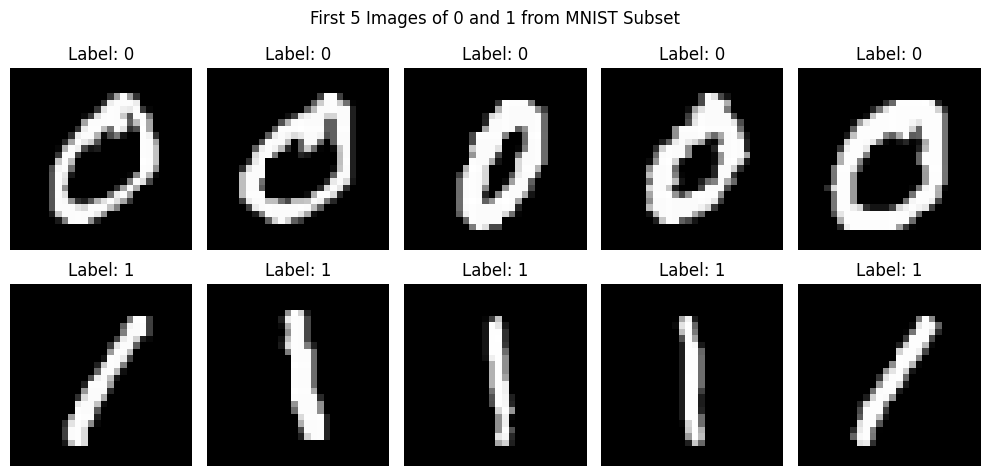

In [9]:
# ── Visualise dataset ────────────────────────────────────────────────────────
images_0 = X[y == 0]
images_1 = X[y == 1]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

if len(images_0) < 5 or len(images_1) < 5:
    print("Error: Not enough images to plot 5 per class.")
else:
    for i in range(5):
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 0")
        axes[0, i].axis("off")

        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 1")
        axes[1, i].axis("off")

plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
plt.tight_layout()
plt.show()


In [10]:
# ── Initialise weights & bias ─────────────────────────────────────────────────
weights       = np.zeros(X.shape[1])   # 784 weights, one per pixel
bias          = 0
learning_rate = 0.1
epochs        = 100

print("Weights shape:", weights.shape)
print("Initial bias :", bias)


Weights shape: (784,)
Initial bias : 0


### Question 3: What does the weights array represent?

`weights` is a 1-D array of **784 values** (one per pixel). Each weight encodes how much influence the corresponding pixel has on the perceptron's final decision. During training, pixels that are strongly predictive of a class will receive large positive or negative weights; uninformative pixels will stay near zero.

### Question 4: Why initialise weights to zero? What effect could this have?

Zero-initialisation is a neutral, reproducible starting point. However, for a *single* perceptron it causes no symmetry problem (unlike in multi-layer networks where all neurons would learn the same thing). The main effect is that early updates are driven entirely by the error signal — the perceptron will still converge as long as the data are linearly separable, but convergence may be slightly slower than with small random initialisation because the very first predictions are all identical (all 0 when the sum is 0).


In [11]:
# ── Decision / Activation function ──────────────────────────────────────────
def decision_function(X, weights, bias):
    """
    Compute predicted labels using the step activation function.
    Parameters:
        X       : numpy array (n_samples, n_features)
        weights : numpy array (n_features,)
        bias    : scalar
    Returns:
        y_pred_all : numpy array of 0/1 predictions
    """
    # Weighted sum for every sample at once (vectorised)
    net_input = np.dot(X, weights) + bias

    # Step function: output 1 if net_input >= 0, else 0
    y_pred_all = np.where(net_input >= 0, 1, 0)

    return y_pred_all


In [12]:
# ── Perceptron Learning Algorithm ─────────────────────────────────────────────
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train the perceptron using the Perceptron Learning Algorithm.
    Parameters:
        X             : (n_samples, n_features) feature matrix
        y             : (n_samples,) true labels
        weights       : initial weight vector
        bias          : initial bias
        learning_rate : step size for updates
        epochs        : maximum number of full passes over the data
    Returns:
        weights  : learned weights
        bias     : learned bias
        accuracy : fraction of correctly classified samples (final epoch)
    """
    n_samples = X.shape[0]
    accuracy  = 0.0

    for epoch in range(epochs):
        convergence_flag = True   # assume converged until a mistake is found
        correct = 0

        for i in range(n_samples):
            # Compute weighted sum (net input)
            output = np.dot(X[i], weights) + bias

            # Apply step activation function
            y_hat = 1 if output >= 0 else 0

            # Count correct predictions
            if y_hat == y[i]:
                correct += 1
            else:
                # Update weights and bias only when prediction is wrong
                error    = y[i] - y_hat
                weights += learning_rate * error * X[i]
                bias    += learning_rate * error
                convergence_flag = False   # at least one mistake → not yet converged

        accuracy = correct / n_samples

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch + 1:3d}/{epochs} | Accuracy: {accuracy:.4f}")

        # Early stopping: if no weight update occurred, the data are perfectly classified
        if convergence_flag:
            print(f"\nConverged at epoch {epoch + 1}!")
            break

    return weights, bias, accuracy


### Question 5: Purpose of `output = np.dot(X[i], weights) + bias`

This line computes the **net input** (weighted sum) for sample *i*:

$$z = \sum_{j=1}^{784} w_j \cdot x_{ij} + b$$

It is a dot product of the 784 pixel values with the 784 corresponding weights, plus the bias. The result *z* is then passed through the step function to yield a prediction of 0 or 1.

### Question 6: What happens when the prediction is wrong?

When `y_hat ≠ y[i]`, the **perceptron learning rule** fires:

- **Weight update:** `weights += learning_rate × (y - y_hat) × X[i]`  
  If the true label is 1 but we predicted 0 (`error = +1`), all weights for active pixels are increased, making the neuron more likely to fire for similar inputs next time. The opposite happens when we predict 1 but the label is 0 (`error = −1`).

- **Bias update:** `bias += learning_rate × (y - y_hat)`  
  Shifts the decision boundary up or down, independent of the input features.

### Question 7: Why is final accuracy important, and what do we expect?

Final accuracy shows whether the perceptron has learned to separate the two classes. For the 0 vs 1 task — one of the *easiest* MNIST pairs because the digit shapes are very dissimilar — we expect accuracy to be **very high (≥ 99%)**, likely reaching 100% (perfect convergence) because 0 and 1 are nearly linearly separable in pixel space.


In [13]:
# ── Train ─────────────────────────────────────────────────────────────────────
# Re-initialise so the cell is idempotent
weights = np.zeros(X.shape[1])
bias    = 0

weights, bias, accuracy = train_perceptron(X, y, weights, bias,
                                           learning_rate=0.1, epochs=100)
print(f"\nFinal Training Accuracy: {accuracy:.4f}")


Epoch  10/100 | Accuracy: 0.9992

Converged at epoch 13!

Final Training Accuracy: 1.0000


In [14]:
# ── Visualise misclassified images ────────────────────────────────────────────
predictions = np.dot(X, weights) + bias
y_pred      = np.where(predictions >= 0, 1, 0)

final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy (post-training check): {final_accuracy:.4f}")

misclassified_idx = np.where(y_pred != y)[0]

if len(misclassified_idx) > 0:
    n_show = min(10, len(misclassified_idx))
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:n_show]):
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred:{y_pred[idx]}, True:{y[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images – 0 vs 1")
    plt.tight_layout()
    plt.show()
    print(f"Total misclassified: {len(misclassified_idx)}")
else:
    print("All images were correctly classified!")


Final Accuracy (post-training check): 1.0000
All images were correctly classified!


### Question 8: What does `misclassified_idx` store, and how is it used?

`misclassified_idx` is a 1-D numpy array of **integer indices** pointing to every sample where the perceptron's prediction (`y_pred[i]`) does not match the true label (`y[i]`). It is then used to:
1. Count the total number of errors (`len(misclassified_idx)`).
2. Fetch the raw pixel data (`X[idx]`) for each wrongly classified image.
3. Reshape that pixel data to 28 × 28 and display it with `imshow`, annotated with both the predicted and the true label.

### Question 9: How to interpret "All images were correctly classified!"?

It means the perceptron achieved **100% training accuracy** — it found a linear decision boundary (a hyperplane in 784-D space) that perfectly separates every 0 from every 1 in the training set. For the 0 vs 1 task this is expected: the two digit classes are visually very distinct and their pixel representations are linearly separable, so the Perceptron Convergence Theorem guarantees convergence to an exact solution.


---
## Task 3: Perceptron Algorithm for 3 vs 5 Classification (MNIST)


In [16]:
# ── Load dataset ──────────────────────────────────────────────────────────────
df_3_5 = pd.read_csv("/content/drive/MyDrive/AI-ML/mnist_3_and_5.csv")

X35 = df_3_5.drop(columns=["label"]).values
y35 = df_3_5["label"].values

# Remap labels to 0/1  (3 → 0,  5 → 1) so the step function works correctly
y35_binary = np.where(y35 == 3, 0, 1)

print("Feature matrix shape:", X35.shape)
print("Label vector shape  :", y35.shape)
print("Unique original labels:", np.unique(y35))


Feature matrix shape: (2741, 784)
Label vector shape  : (2741,)
Unique original labels: [3 5]


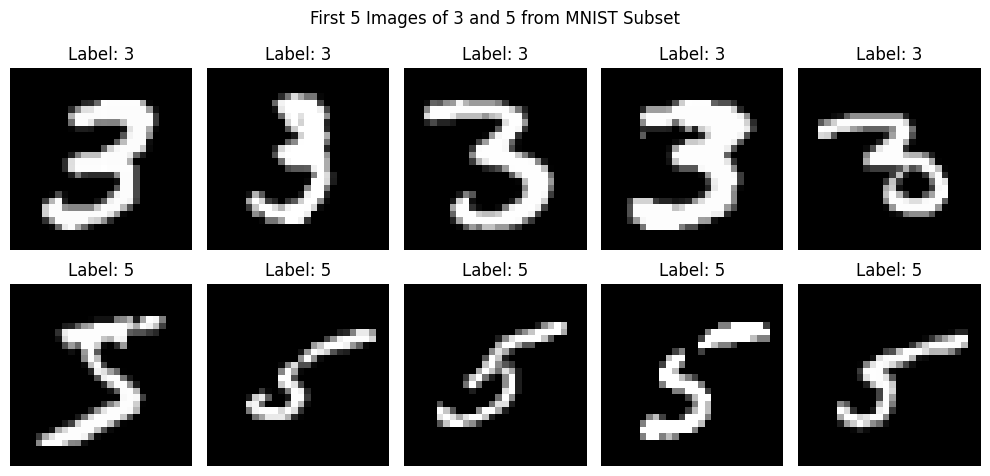

In [17]:
# ── Visualise dataset ────────────────────────────────────────────────────────
images_3 = X35[y35 == 3]
images_5 = X35[y35 == 5]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

if len(images_3) < 5 or len(images_5) < 5:
    print("Not enough images to display.")
else:
    for i in range(5):
        axes[0, i].imshow(images_3[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 3")
        axes[0, i].axis("off")

        axes[1, i].imshow(images_5[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 5")
        axes[1, i].axis("off")

plt.suptitle("First 5 Images of 3 and 5 from MNIST Subset")
plt.tight_layout()
plt.show()


In [18]:
# ── Initialise weights & bias ─────────────────────────────────────────────────
weights35 = np.zeros(X35.shape[1])
bias35    = 0

print("Weights shape:", weights35.shape)


Weights shape: (784,)


In [19]:
# ── Train ─────────────────────────────────────────────────────────────────────
weights35, bias35, accuracy35 = train_perceptron(
    X35, y35_binary, weights35, bias35,
    learning_rate=0.1, epochs=100
)
print(f"\nFinal Training Accuracy (3 vs 5): {accuracy35:.4f}")


Epoch  10/100 | Accuracy: 0.9566
Epoch  20/100 | Accuracy: 0.9661
Epoch  30/100 | Accuracy: 0.9726
Epoch  40/100 | Accuracy: 0.9719
Epoch  50/100 | Accuracy: 0.9788
Epoch  60/100 | Accuracy: 0.9759
Epoch  70/100 | Accuracy: 0.9792
Epoch  80/100 | Accuracy: 0.9792
Epoch  90/100 | Accuracy: 0.9843
Epoch 100/100 | Accuracy: 0.9858

Final Training Accuracy (3 vs 5): 0.9858


Final Accuracy (3 vs 5): 0.9869


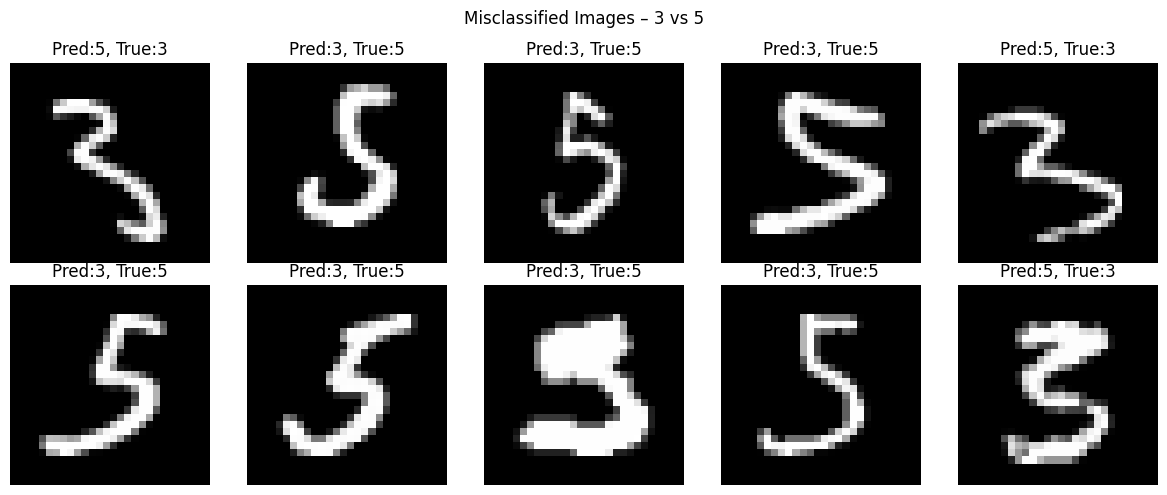

Total misclassified: 36 / 2741


In [20]:
# ── Visualise misclassified images ────────────────────────────────────────────
preds35    = np.dot(X35, weights35) + bias35
y_pred35   = np.where(preds35 >= 0, 1, 0)

# Map back to original labels for display
y_pred35_labels = np.where(y_pred35 == 0, 3, 5)

final_acc35 = np.mean(y_pred35 == y35_binary)
print(f"Final Accuracy (3 vs 5): {final_acc35:.4f}")

misclassified35 = np.where(y_pred35_labels != y35)[0]

if len(misclassified35) > 0:
    n_show = min(10, len(misclassified35))
    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    for ax, idx in zip(axes.flat, misclassified35[:n_show]):
        ax.imshow(X35[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred:{y_pred35_labels[idx]}, True:{y35[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images – 3 vs 5")
    plt.tight_layout()
    plt.show()
    print(f"Total misclassified: {len(misclassified35)} / {len(y35)}")
else:
    print("All images were correctly classified!")


### Conclusion – 3 vs 5 Classification

**Why is 3 vs 5 harder than 0 vs 1?**

The digits 3 and 5 share many visual features — both have curved strokes and similar overall shapes — making them harder to separate with a **linear** decision boundary. As a result:

- The perceptron is **unlikely to converge** within 100 epochs (no perfect linear separation exists).
- Final accuracy will be **lower** than for 0 vs 1, typically around 90–95%.
- The misclassified images (as shown in Figure 6 of the worksheet) tend to be ambiguously written digits that even humans can confuse.

**What does this tell us about the perceptron's limitations?**

| Limitation | Explanation |
|---|---|
| Linear decision boundary | A perceptron can only draw a single straight hyperplane to separate classes. When classes are not linearly separable (like 3 vs 5), it will always have some errors. |
| No hidden representation | Without hidden layers the model cannot learn complex, non-linear features. |
| Sensitive to noise | Ambiguously written digits easily cross the linear boundary. |

**Solution:** To overcome these limitations, we need **multi-layer perceptrons (MLP)** or deeper neural networks that can learn non-linear decision boundaries through multiple layers of weighted transformations and non-linear activations.
